Initial Shape: (52500, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52500 entries, 0 to 52499
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            51496 non-null  object 
 1   Product_Name          51433 non-null  object 
 2   Brand                 51420 non-null  object 
 3   Category              51437 non-null  object 
 4   Market_Price          51488 non-null  float64
 5   Purchase_Amount       51434 non-null  float64
 6   Discount_Applied      51410 non-null  object 
 7   Rating                51462 non-null  float64
 8   Customer_ID           51437 non-null  object 
 9   Age                   51461 non-null  float64
 10  Gender                51469 non-null  object 
 11  City                  51430 non-null  object 
 12  Purchase_Date         51413 non-null  object 
 13  Payment_Method        51440 non-null  object 
 14  Repeat_Customer       51481 non-null  objec

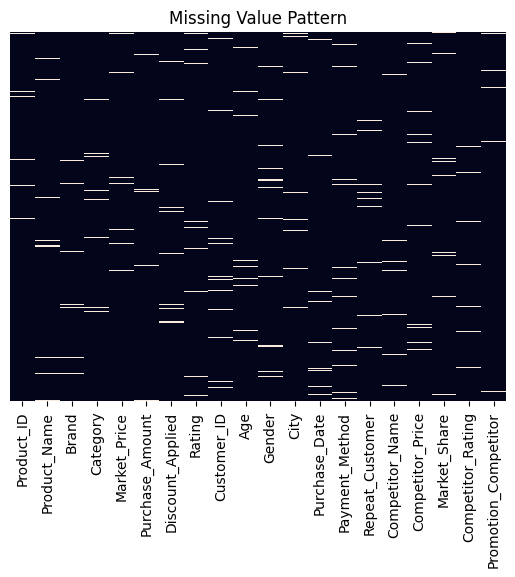

Duplicate rows: 2313
Product_ID duplicate values: 3452
Product_Name duplicate values: 52483
Brand duplicate values: 52483
Category duplicate values: 52495
Market_Price duplicate values: 19600
Purchase_Amount duplicate values: 21661
Discount_Applied duplicate values: 52497
Rating duplicate values: 52494
Customer_ID duplicate values: 3511
Age duplicate values: 52456
Gender duplicate values: 52496
City duplicate values: 27715
Purchase_Date duplicate values: 52133
Payment_Method duplicate values: 52495
Repeat_Customer duplicate values: 52497
Competitor_Name duplicate values: 52494
Competitor_Price duplicate values: 52484
Market_Share duplicate values: 52491
Competitor_Rating duplicate values: 52490
Promotion_Competitor duplicate values: 52497
Negative values check:
Market_Price 0
Purchase_Amount 0
Rating 0
Age 0
Competitor_Price 0
Market_Share 0
Competitor_Rating 0
Extreme outliers injected


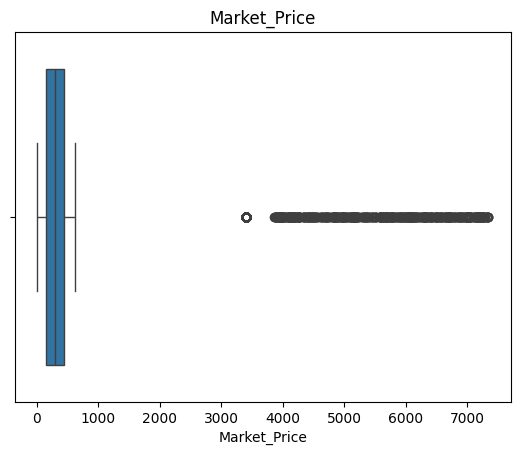

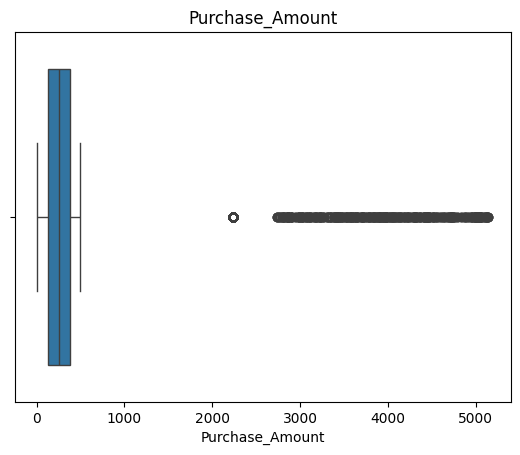

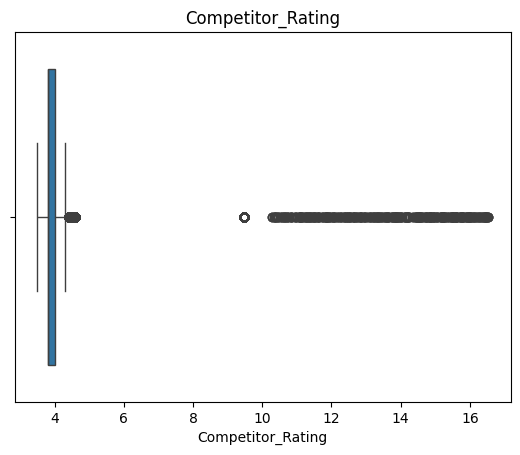

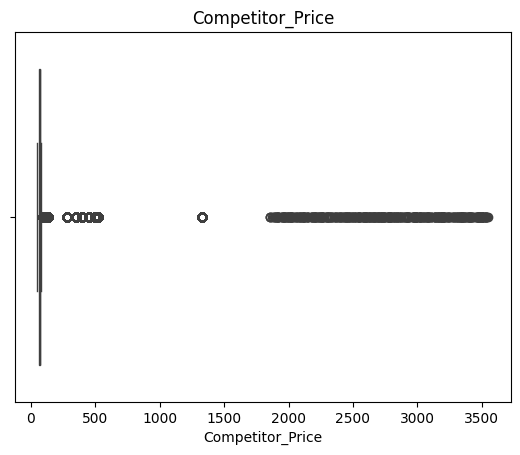

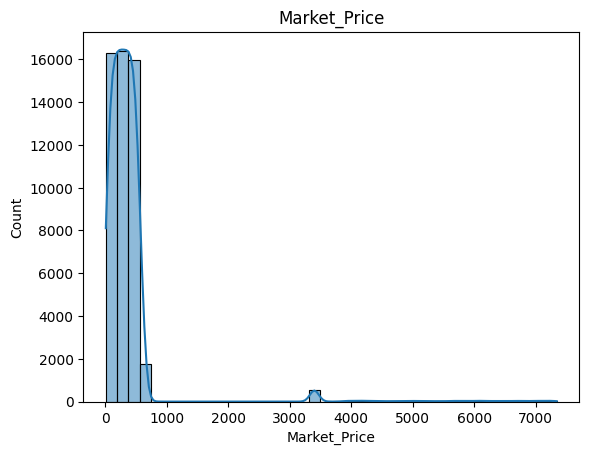

Market_Price | Shapiro p-value: 1.0


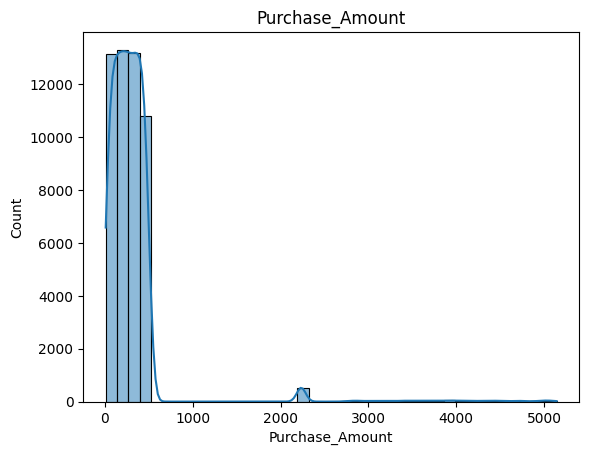

Purchase_Amount | Shapiro p-value: 1.0


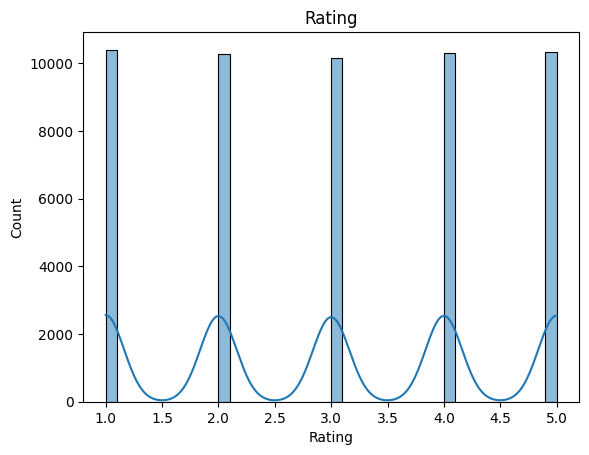

Rating | Shapiro p-value: 1.0


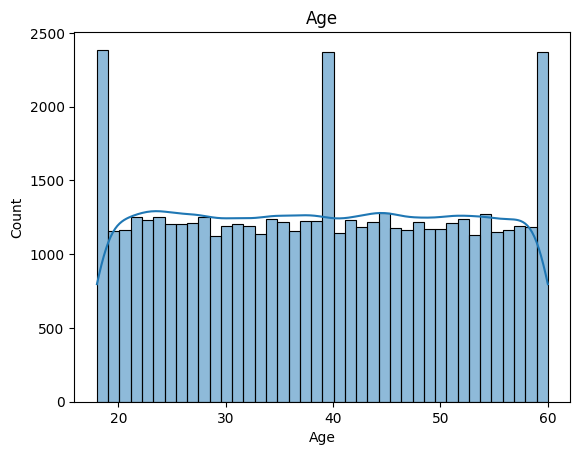

Age | Shapiro p-value: 1.0


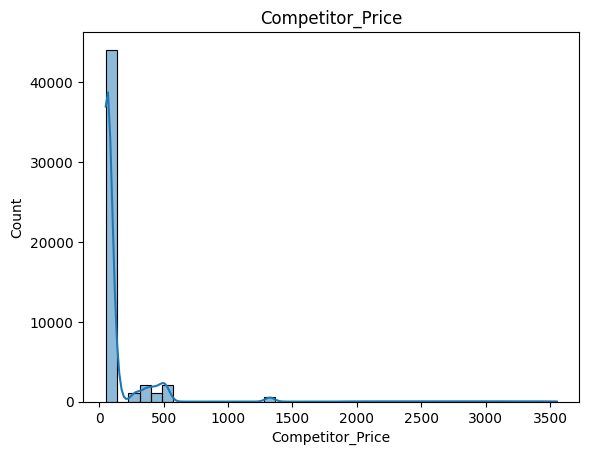

Competitor_Price | Shapiro p-value: 1.0


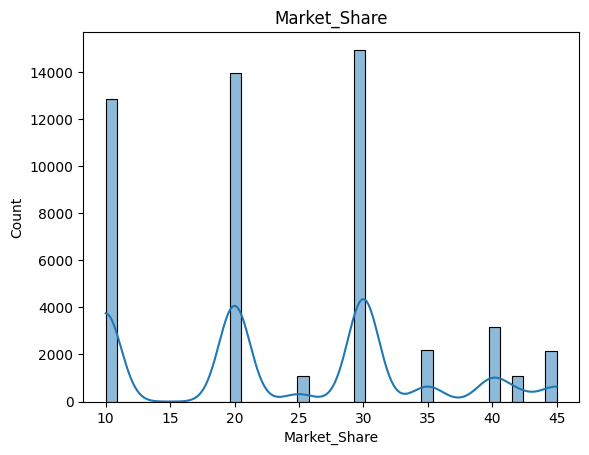

Market_Share | Shapiro p-value: 1.0


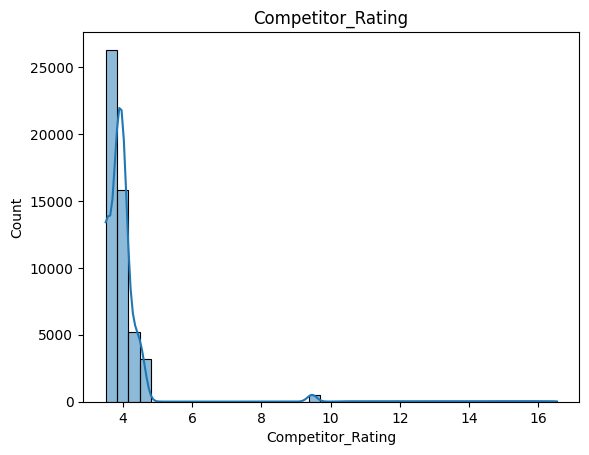

Competitor_Rating | Shapiro p-value: 1.0


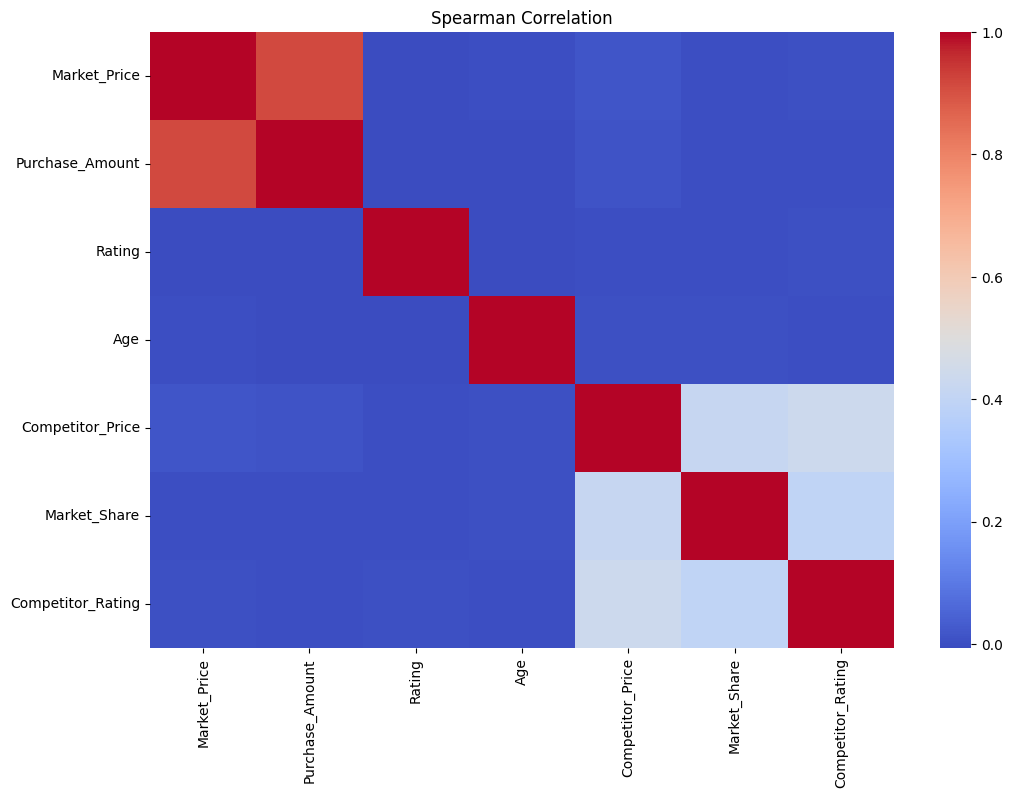

             feature       VIF
0       Market_Price  1.329844
1    Purchase_Amount  1.461241
2             Rating  4.248746
3                Age  6.345927
4   Competitor_Price  1.229586
5       Market_Share  5.000098
6  Competitor_Rating  7.371311
Product_ID unique values: 49047
Product_Name unique values: 16
Brand unique values: 16
Category unique values: 4
Discount_Applied unique values: 2
Customer_ID unique values: 48988
Gender unique values: 3
City unique values: 24784
Purchase_Date unique values: 366
Payment_Method unique values: 4
Repeat_Customer unique values: 2
Competitor_Name unique values: 5
Promotion_Competitor unique values: 2
GOLD STANDARD EDA COMPLETED


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
df = pd.read_csv(
    r"C:\Users\USER\Desktop\Sales_Forecasting-Inventory_Management\data\Walmart_modified_with_anomalies.csv"
)

print('Initial Shape:', df.shape)


# ------------------------------------------------------------
# 1. DATA OVERVIEW
# ------------------------------------------------------------
print(df.info())
print(df.describe().T)

# ------------------------------------------------------------
# 2. MISSING VALUES ANALYSIS
# ------------------------------------------------------------
missing = pd.DataFrame({
    'count': df.isna().sum(),
    'percent': df.isna().mean() * 100
}).sort_values('percent', ascending=False)
print(missing)

sns.heatmap(df.isna(), cbar=False, yticklabels=False)
plt.title('Missing Value Pattern')
plt.show()

# ------------------------------------------------------------
# 3. DUPLICATE ANALYSIS
# ------------------------------------------------------------
print('Duplicate rows:', df.duplicated().sum())
for col in df.columns:
    print(f'{col} duplicate values:', df[col].duplicated().sum())

# ------------------------------------------------------------
# 4. BUSINESS RULE & RANGE CHECKS (NUMERIC)
# ------------------------------------------------------------
num_cols = df.select_dtypes(include=np.number).columns
print('Negative values check:')
for col in num_cols:
    neg = (df[col] < 0).sum()
    print(col, neg)

# ------------------------------------------------------------
# 5. SYNTHETIC EXTREME OUTLIER INJECTION (10–20 STD)
# ------------------------------------------------------------
outlier_cols = ['Market_Price', 'Purchase_Amount', 'Competitor_Rating', 'Competitor_Price']
np.random.seed(42)

for col in outlier_cols:
    if col in df.columns:
        mean, std = df[col].mean(), df[col].std()
        n = int(len(df) * 0.01)
        df.loc[np.random.choice(df.index, n, replace=False), col] = \
            mean + np.random.uniform(10, 20, n) * std

print('Extreme outliers injected')

# ------------------------------------------------------------
# 6. OUTLIER VISUALIZATION
# ------------------------------------------------------------
for col in outlier_cols:
    if col in df.columns:
        sns.boxplot(x=df[col])
        plt.title(col)
        plt.show()

# ------------------------------------------------------------
# 7. DISTRIBUTION & NORMALITY TESTS
# ------------------------------------------------------------
for col in num_cols:
    sns.histplot(df[col], kde=True, bins=40)
    plt.title(col)
    plt.show()

    stat, p = stats.shapiro(df[col].sample(min(5000, len(df))))
    print(f'{col} | Shapiro p-value: {p}')

# ------------------------------------------------------------
# 8. CORRELATION & MULTICOLLINEARITY
# ------------------------------------------------------------
plt.figure(figsize=(12, 8))
sns.heatmap(df[num_cols].corr(method='spearman'), cmap='coolwarm')
plt.title('Spearman Correlation')
plt.show()

vif_df = pd.DataFrame()
vif_df['feature'] = num_cols
vif_df['VIF'] = [
    variance_inflation_factor(df[num_cols].fillna(0).values, i)
    for i in range(len(num_cols))
]
print(vif_df)

# ------------------------------------------------------------
# 9. CATEGORICAL CARDINALITY
# ------------------------------------------------------------
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(col, 'unique values:', df[col].nunique())

print('GOLD STANDARD EDA COMPLETED')
